## 파이토치에서의 임베딩 사용법
#### 1. nn.Embedding()

`단어 → 단어에 부여된 고유한 정수값 → 임베딩 층 통과 → 밀집 벡터`

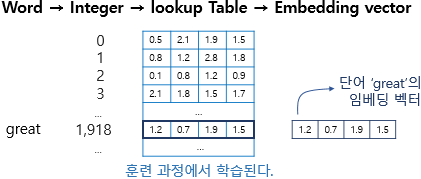

In [2]:
train_data = 'you need to know how to code'

word_set = set(train_data.split())

vocab = {word: i+2 for i, word in enumerate(word_set)}
vocab['<unk>'] = 0
vocab['<pad>'] = 1
vocab

{'to': 2,
 'how': 3,
 'need': 4,
 'code': 5,
 'you': 6,
 'know': 7,
 '<unk>': 0,
 '<pad>': 1}

In [3]:
import torch

In [4]:
embedding_table = torch.FloatTensor([
                               [ 0.0,  0.0,  0.0],
                               [ 0.0,  0.0,  0.0],
                               [ 0.2,  0.9,  0.3],
                               [ 0.1,  0.5,  0.7],
                               [ 0.2,  0.1,  0.8],
                               [ 0.4,  0.1,  0.1],
                               [ 0.1,  0.8,  0.9],
                               [ 0.6,  0.1,  0.1]])

In [8]:
sample = 'you need to run'.split()
idxes = []

for word in sample:
    try:
        idxes.append(vocab[word])
    #vocab에 없는 단어일 경우 <unk>로 대체
    except KeyError:
        idxes.append(vocab['<unk>'])

idxes = torch.LongTensor(idxes)

lookup_result = embedding_table[idxes, :]
print(lookup_result)

tensor([[0.1000, 0.8000, 0.9000],
        [0.2000, 0.1000, 0.8000],
        [0.2000, 0.9000, 0.3000],
        [0.0000, 0.0000, 0.0000]])


In [9]:
import torch.nn as nn

In [ ]:
train_data = 'you need to know how to code'

word_set = set(train_data.split())

vocab = {word: i+2 for i, word in enumerate(word_set)}
vocab['<unk>'] = 0
vocab['<pad>'] = 1

# num_embeddings: 단어 집합의 크기(임베딩 할 단어의 개수)
# embedding_dim: 임베딩 할 벡터의 차원
# padding_idx: 패딩을 위한 토큰의 인덱스
embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=3, padding_idx=1)

In [12]:
print(embedding_layer.weight)

Parameter containing:
tensor([[-0.6297, -0.7955, -1.1581],
        [ 0.0000,  0.0000,  0.0000],
        [-0.6194, -0.2182, -0.5009],
        [ 1.2198, -0.5765, -0.6882],
        [-0.9468,  1.1917,  1.5853],
        [ 0.7562, -2.8254, -1.9139],
        [ 1.1721, -0.0796, -0.6975],
        [-3.0987, -0.8797,  1.0103]], requires_grad=True)


#### 2. Pre-trained-Word Embedding

In [13]:
import numpy as np
from collections import Counter

In [16]:
sentences = ['nice great best amazing', 'stop lines', 'pitiful nerd', 'excellent work', 'supreme quality', 'bad','highly respectable']
y_train = [1,0,0,1,1,0,1]

In [17]:
tokenized_sentences = [sent.split() for sent in sentences]

In [18]:
word_list = []
for sent in tokenized_sentences:
    for word in sent:
        word_list.append(word)
word_counts = Counter(word_list)
print('총 단어수: ', len(word_counts))

총 단어수:  15


In [20]:
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
vocab

['nice',
 'great',
 'best',
 'amazing',
 'stop',
 'lines',
 'pitiful',
 'nerd',
 'excellent',
 'work',
 'supreme',
 'quality',
 'bad',
 'highly',
 'respectable']

In [21]:
word_to_index = {}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1
for index, word in enumerate(vocab):
    word_to_index[word] = index+2

vocab_size = len(word_to_index)

In [22]:
word_to_index

{'<PAD>': 0,
 '<UNK>': 1,
 'nice': 2,
 'great': 3,
 'best': 4,
 'amazing': 5,
 'stop': 6,
 'lines': 7,
 'pitiful': 8,
 'nerd': 9,
 'excellent': 10,
 'work': 11,
 'supreme': 12,
 'quality': 13,
 'bad': 14,
 'highly': 15,
 'respectable': 16}

In [23]:
def texts_to_sequences(tokenized_X_data, word_to_index):
    encoded_X_data = []
    for sent in tokenized_X_data:
        index_sequences = []
        for word in sent:
            try:
                index_sequences.append(word_to_index[word])
            except KeyError:
                index.sequences.append(word_to_index['<UNK>'])
        encoded_X_data.append(index_sequences)
    return encoded_X_data

In [27]:
X_encoded = texts_to_sequences(tokenized_sentences, word_to_index)
max_len = max(len(l) for l in X_encoded)
X_encoded

[[2, 3, 4, 5], [6, 7], [8, 9], [10, 11], [12, 13], [14], [15, 16]]

In [ ]:
def pad_sequences(sentences, max_len):
    features = np.zero((len(sentences), max_len), dtype=int)
    for index, sentence in enumerate(sentences):
        if len(sentence) != 0:
            features[index, :len(sentence)] = np.array